## WP2.2 
### normalisation and standardisation of water quality measures. 

#### A: Instrument  to Intrument harmonisation:
1. generate **daily** results for some sites, for the year 2020 (all instruments available)
2. compare results for the same algorithm, between sensors: ETM-OLI, OLI-MSI
(Choose sites to ***be re-used for calibration against in-situ data*** (i.e. lake victoria)
3. Move on to harmonisation between measurements!
 
#### B: Measurement to Measurement harmonisation :
1. generate results for all sites
   - results include the observed distribution of each WQ variable - this is in quantiles
3. compile results to a singlle dataset
4. choose a reference measrement
5. determine the adjustment parameters to adjust other measures to the statistical space of the reference measure
   - this includes the **time intervals** to use 
   - Simplest case: match the medians and the 1% quantile **for all times and places**
   - More sophisticated : match probability distributions to an ensemble model (pending)


In [26]:
# ---  dependencies --- 

import datacube
import numpy as np
import xarray as xr
import scipy as sp
import gc
import json
from scipy import stats
import pandas as pd     #for dates
from odc.ui import image_aspect
from deafrica_tools.plotting import rgb # used in some visualisation for debugging
#dc = datacube.Datacube(app='DoinWhatImdoin') #testing what difference the 'app' value makes...

In [27]:
# --- pathnames 
# results files are stored in my space for now
results_directory = '/home/jovyan/deafrica_water_quality/wq_results/'
WP12              = '/home/jovyan/dev/deafrica_water_quality/WP1.2'
WP22              = '/home/jovyan/dev/deafrica_water_quality/WP2.2'
all_results_filename    = 'wq_raw'
annual_results_filename  = 'annsummary'
parta_results_filename   = '22A'

In [40]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py   
#%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_Build_annual_dataset-1.0.ipynb   #for now I have kept these functions in a notebook for the markdown

# Part A, Instrument to Instrument Harmonisation

## Build datasets from daily observations for key sites

- as well as the primary data, we are going to need wofs to determine water areas, and the geomedians to help filter outliers (perhaps).

#### Parameters -- including a list of places to process 

In [53]:
# --- controlling parameters and settings
verbose = True 
test    = False
# --- the number of cells in the spatial domain (x,y) used to analyse the waterbody ; Data are resampled guided by this limit 
max_cells = 100000   
max_cells = 50000   #use this to test memory limits. Memory saving steps are going to be needed...
max_cells = 10000   #use this to test memory limits. Memory saving steps are going to be needed...
year1, year2 = '2019-01-01','2020-12-31' #this is a good start interval for instrument cross-referencing

# --- get the dictionary of all possible places for analysis ---
places_dict     = set_spacetime_domain()   
process_list = ['Lake_Baringo', 
           'Senegal_StLouis', 
           'Lake_Sulunga', 'Lake_Mweru',
            'Ghana_River', 
            'Lake_vic_turbid', 
            'Morocco', 
            'Thewaterskool_SA',
            'Ethiopia1of2', 
            'Ethiopia2of2', 
            'Ethiopia3of2',
            'SA_smalldam',
            'Lake Chamo', 
            'Lake Ziway', 
            'Lake Alwassa',
            'mombasa', 
            'Lake_Nasser_nth',
            'Lake_Nasser_sth',
            'Lake_Malawi',
            'Barrage Joumine', 
            'Lake_Chilwa', 'Lake_Malombe',
            'Indian_Ocean',
            'Haartbeesport_dam', 'Lake Bogoria',
            'HC_1',
            'HC_2',
            'HC_3',
            'HC_4',
            'HC_5',
            'HC_6']
# a core list to get started with
process_list = ['HC_1','HC_2','HC_3','HC_4','HC_5','HC_6']
process_list = ['Haartbeesport_dam']

# --- looks like these are the non-geomedian instruments...
instruments_to_use = {
    'oli_agm'  : {'use': False },
    'oli'      : {'use': True},
    'msi_agm'  : {'use': False },
    'msi'      : {'use': True},
    'tm_agm'   : {'use': False },
    'tm'       : {'use': True},
    'tirs'     : {'use': True},  
    'wofs_ann' : {'use': False },
    'wofs_all' : {'use': False },  # wofs_all will be removed as it is better to derive from wofs_ann
    }

In [54]:
y1 = pd.DatetimeIndex([year1]).year[0]
y2 = pd.DatetimeIndex([year2]).year[0]

In [135]:
gm_instruments_to_use = check_instrument_dates(gm_instruments_to_use,gm_years[0],gm_years[1],verbose=False)
gm_instruments,gm_measurements,gm_rename_dict   = instruments_list(gm_instruments_to_use)

{'wofs_ann': (('frequency', 'wofs_ann_freq'),
  ('count_clear', 'wofs_ann_clearcount'),
  ('count_wet', 'wofs_ann_wetcount')),
 'oli_agm': (('SR_B2', 'oli02_agm'),
  ('SR_B3', 'oli03_agm'),
  ('SR_B4', 'oli04_agm'),
  ('SR_B5', 'oli05_agm'),
  ('SR_B6', 'oli06_agm'),
  ('SR_B7', 'oli07_agm'),
  ('smad', 'oli_agm_smad'),
  ('emad', 'oli_agm_emad'),
  ('bcmad', 'oli_agm_bcmad'),
  ('count', 'oli_agm_count')),
 'msi_agm': (('B02', 'msi02_agm'),
  ('B03', 'msi03_agm'),
  ('B04', 'msi04_agm'),
  ('B05', 'msi05_agm'),
  ('B06', 'msi06_agm'),
  ('B07', 'msi07_agm'),
  ('B8A', 'msi8a_agm'),
  ('B11', 'msi11_agm'),
  ('B12', 'msi12_agm'),
  ('smad', 'msi_agm_smad'),
  ('emad', 'msi_agm_emad'),
  ('bcmad', 'msi_agm_bcmad'),
  ('count', 'msi_agm_count'))}

In [55]:
instruments_to_use = check_instrument_dates(instruments_to_use,y1,y2,False)

products = { 
                'tm_agm'  :["gm_ls5_ls7_annual"],
                'tm'      :["ls5_sr","ls7_sr"],
                'oli_agm' :["gm_ls8_annual","gm_ls8_ls9_annual"],
                'oli'     :["ls8_sr","ls9_sr"],
                'msi_agm' :["gm_s2_annual"],
                'msi'     :["s2_l2a"],
                'tirs'    :["ls5_st","ls7_st","ls8_st","ls9_st"],
                'wofs_ann':["wofs_ls_summary_annual"],
                'wofs_all':["wofs_ls_summary_alltime"],
               }

instruments,measurements,rename_dict = instruments_list(instruments_to_use) 
data_list = {}

In [56]:
# start a log file (don't use the append option at this point)

logfilename = 'parta_log.csv'
a_log = open_logfile(places_dict,
                     logfilename,
                     overwrite='Append',   # alternatively use True or False
                     include_list=process_list)
#reduce the log file to the places we are specifically interested in; this seems messy
droplist = list(set(a_log.PlaceName) - set(process_list))
for name in droplist:   a_log.drop(a_log[a_log.PlaceName==name].index,inplace=True)
a_log.reset_index(inplace=True,drop=True)

appending


In [57]:
# reset to start again :
# a_log.loc[a_log['PlaceName']==placename,'Status'] = 0


In [58]:
a_log

,Unnamed: 0.1,Unnamed: 0,PlaceName,Status,RunNumber,Year1,Year2
0,0,15,Haartbeesport_dam,0,0,0,0


In [59]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py   
#%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_Build_annual_dataset-1.0.ipynb   #for now I have kept these functions in a notebook for the markdown


In [ ]:
# this is a test that _WP_2.2_functions.py has successfully imported other functions...
wp22_dummy()

In [ ]:
# this process first builds the annual dataset and then builds the specific dataset
over_write = False # to overwrite previous results
verbose    = False
for placename in a_log.PlaceName:
#if True:
    if a_log.loc[a_log.PlaceName==placename,'Status'].item() < 100 :
        results_filename = parta_results_filename+'_'+placename+'.nc'
        if os.path.exists(results_directory+results_filename) : 
            if not over_write :
                a_log = log_update(a_log,placename,100,logfilename)

        spacetime_domain, grid_resolution, cell_area, resampling_option, year1, year2 \
                           = set_spacetime_domain(placename,year1,year2,max_cells,verbose,False)
        parameters = store_parameters(placename,
                                          spacetime_domain,
                                          grid_resolution,
                                          cell_area,
                                          resampling_option,
                                          year1,
                                          year2)

        # --- set the years and instruments for the geomedian data
        # --- the basics are stashed away in this function:
        gm_years,gm_instruments_to_use = geomedian_instruments_and_years(parameters)
        # --- different years are needed for the geomedians to give a 5 year interval
        gm_parameters = parameters              # --- store the parameters for reference 
        gm_parameters['year1'] = gm_years[0]
        gm_parameters['year2'] = gm_years[1]
        # --- check the proposed years against the geomedian dataset dates ---
        gm_instruments_to_use = check_instrument_dates(gm_instruments_to_use,gm_years[0],gm_years[1],verbose=False)
        # --- get the full detail, the gm_instruments is used later, the other parts not 
        gm_instruments,gm_measurements,gm_rename_dict   = instruments_list(gm_instruments_to_use)
        
        i = 1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i or True:
            ds_annual = build_agm_dataset(gm_parameters,gm_instruments_to_use)
            a_log = log_update(a_log,placename,i,logfilename)
        i += 1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual = detect_geomedian_instruments(ds_annual)
            a_log = log_update(a_log,placename,i,logfilename)

        i +=1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual = calculate_agm_count(ds_annual)
            a_log = log_update(a_log,placename,i,logfilename)
            a_log = log_update(a_log,placename,i,logfilename)
 

        i +=1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
        # --- controling parameters for water mapping on a pixel by pixel basis ---
            WFTH = water_frequency_threshold_high = 0.5    #this threshold targets areas that are as like as not to be water at any time.
            PWT  = permanent_water_threshold      = 0.875  #used to map annual permanent water (value arrived at through testing)
            SC   = sigma_coefficient              = 1.2    #used to map annual permanent water (value arrived at through tessting)
            ds_annual   = water_analysis(ds_annual,
                   water_frequency_threshold= WFTH,
                   wofs_varname             = 'wofs_ann_freq',
                   permanent_water_threshold= PWT,
                   sigma_coefficient        = SC,
                   verbose                  = True,
                   test                     = test)
            a_log = log_update(a_log,placename,i,logfilename)

        i +=1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual              = WOFS_5_year_frequency(ds_annual,False)
            a_log = log_update(a_log,placename,i,logfilename)
        i +=1 

        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual['water_5yr'] = xr.where(ds_annual.wofs_5yr_freq>0.45,
                                                  ds_annual.wofs_5yr_freq.astype('bool'),np.nan)
            a_log = log_update(a_log,placename,i,logfilename)

        i +=1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual              = geomedian_FAI(ds_annual,ds_annual.water_5yr)
            a_log = log_update(a_log,placename,i,logfilename)

        i +=1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual              = set_clearwater(ds_annual)
            a_log = log_update(a_log,placename,i,logfilename)

        i +=1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:      
            ds_annual              = apply_R_correction(ds_annual,['msi_agm','oli_agm','tm_agm'],
                             water_mask=ds_annual.water_5yr,drop = True, test = False,verbose=False)
            a_log = log_update(a_log,placename,i,logfilename)

        i +=1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual = geomedian_hue(ds_annual,ds_annual.clearwater==True,test=True,verbose=True)
            a_log = log_update(a_log,placename,i,logfilename)

        i +=1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual = run_OWT(ds_annual,agm=True,verbose=True)
            a_log = log_update(a_log,placename,i,logfilename)



        i +=1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i and True:
            print('re-running')
            algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='_agm')
            ds_annual,tsm_vlist  = WQ_vars(ds_annual.where(ds_annual.clearwater),
                        algorithms_tsm,  
                        gm_instruments, 
                        new_dimension_name='tss_measure', 
                        new_varname='tss', 
                        verbose=verbose)
            ds_annual,chla_vlist = WQ_vars(ds_annual.where(ds_annual.clearwater),
                        algorithms_chla, 
                        gm_instruments, 
                        new_dimension_name='chla_measure', 
                        new_varname='chla',
                        verbose=verbose)
            a_log = log_update(a_log,placename,i,logfilename)
        i +=1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
             print(i)
        

In [1146]:
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/WP2.2_functions.py   


In [149]:
ds_annual

<xarray.Dataset> Size: 60MB
Dimensions:              (time: 10, y: 81, x: 158, tss_measure: 11,
                          chla_measure: 11)
Coordinates:
  * time                 (time) datetime64[ns] 80B 2015-07-02T11:59:59.999999...
  * y                    (y) float64 648B -3.181e+06 -3.181e+06 ... -3.176e+06
  * x                    (x) float64 1kB 2.682e+06 2.682e+06 ... 2.693e+06
  * tss_measure          (tss_measure) <U14 616B 'ndssi_rg_msi' ... 'spm_qiu_...
  * chla_measure         (chla_measure) <U16 704B 'ndci_msi54' ... 'chla_modi...
    spatial_ref          int32 4B 6933
Data variables: (12/50)
    oli05_agm            (time, y, x) float64 1MB nan nan nan ... nan nan nan
    oli06_agm            (time, y, x) float64 1MB nan nan nan ... nan nan nan
    oli07_agm            (time, y, x) float64 1MB nan nan nan ... nan nan nan
    oli_agm_smad         (time, y, x) float32 512kB nan nan nan ... nan nan nan
    oli_agm_emad         (time, y, x) float32 512kB nan nan nan ... nan nan nan
    oli_agm_bcmad        (time, y, x) float32 512kB nan nan nan ... nan nan nan
    ...                   ...
    oli_agm_hue          (time, y, x) float64 1MB nan nan nan ... nan nan nan
    msi_agm_hue          (time, y, x) float64 1MB nan nan nan ... nan nan nan
    msi_agm_owt          (time, y, x) float32 512kB nan nan nan ... nan nan nan
    oli_agm_owt          (time, y, x) float64 1MB nan nan nan ... nan nan nan
    tss                  (time, y, x, tss_measure) float64 11MB nan nan ... nan
    chla                 (time, y, x, chla_measure) float64 11MB nan nan ... nan
Attributes:
    crs:           epsg:6933
    grid_mapping:  spatial_ref

In [69]:
geomedian_hue(ds,ds.clearwater==1)


 Aborting hue calculation for instrument  oli  due to lack of necessary data bands



<xarray.Dataset> Size: 33MB
Dimensions:              (time: 10, y: 81, x: 158)
Coordinates:
  * time                 (time) datetime64[ns] 80B 2015-07-02T11:59:59.999999...
  * y                    (y) float64 648B -3.181e+06 -3.181e+06 ... -3.176e+06
  * x                    (x) float64 1kB 2.682e+06 2.682e+06 ... 2.693e+06
    spatial_ref          int32 4B 6933
Data variables: (12/46)
    oli05_agm            (time, y, x) float64 1MB 2.165e+03 ... 1.909e+03
    oli06_agm            (time, y, x) float64 1MB 2.975e+03 ... 2.224e+03
    oli07_agm            (time, y, x) float64 1MB 1.874e+03 ... 1.593e+03
    oli_agm_smad         (time, y, x) float32 512kB 0.002413 ... 0.004723
    oli_agm_emad         (time, y, x) float32 512kB 419.0 338.0 ... 555.0 559.0
    oli_agm_bcmad        (time, y, x) float32 512kB 0.04261 0.03363 ... 0.07672
    ...                   ...
    oli04_agm            (time, y, x) float64 1MB 1.082e+03 1.093e+03 ... 923.0
    oli03_agm            (time, y, x) float64 1MB 882.0 877.0 ... 687.0 703.0
    oli02_agm            (time, y, x) float64 1MB 562.0 557.0 ... 447.0 456.0
    agm_hue              (time, y, x) float64 1MB nan nan nan ... nan nan nan
    oli_agm_hue          (time, y, x) float64 1MB nan nan nan ... nan nan nan
    msi_agm_hue          (time, y, x) float64 1MB nan nan nan ... 40.46 40.28
Attributes:
    crs:           epsg:6933
    grid_mapping:  spatial_ref

In [1128]:
if True:
    ds['agm_hue'] = ('time','x','y'), np.zeros((ds.sizes['time'],ds.sizes['x'],ds.sizes['y']))
    count = np.zeros((ds.sizes['time'],ds.sizes['y'],ds.sizes['x']))

    for instr in ['oli','msi','tm'] :
        instr_agm = instr+'_agm'
        if instr_agm in ds.data_vars:
            hue_data = hue_calculation(ds,instr_agm,test=test,verbose=verbose)
            ds[instr_agm+'_hue'] = ('time','y','x'),hue_data.data

            ds['agm_hue'] = ds['agm_hue'] + \
            (
                        xr.where(~np.isnan(ds[instr+'_agm_hue'])  , ds[instr+'_agm_hue'],0) \
                      * xr.where(~np.isnan(ds[instr+'_agm_hue']), ds[instr+'_agm_count'],0) \
            ) 
            count = count + xr.where(~np.isnan(ds[instr+'_agm_hue']), ds[instr+'_agm_count'],0)
    #ds['agm_hue'] = ds['agm_hue'] / count                             
    if True : ds['agm_hue'] = (ds['agm_hue'] / count).where(ds.clearwater)
    else : ds['agm_hue'] = (ds['agm_hue'] / count)
                             


 Aborting hue calculation for instrument  oli  due to lack of necessary data bands



In [71]:
a_log.loc[a_log.PlaceName==placename,'Status']

0    11
Name: Status, dtype: int64

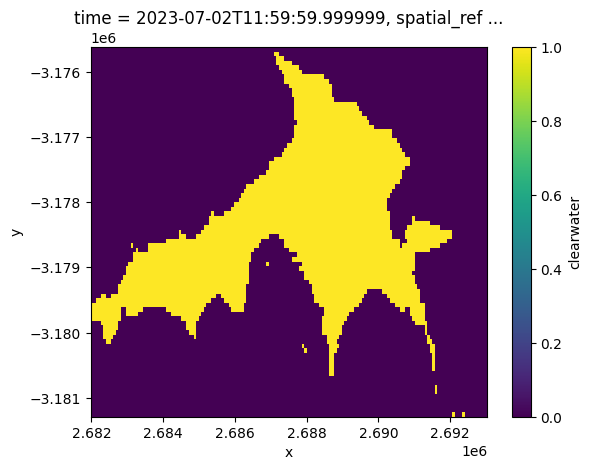

In [70]:
ds.clearwater.isel(time=8).plot()
#ds.clearwater.mean(dim='time').plot()

In [ ]:
                algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='_agm')
                ds_annual,tsm_vlist  = WQ_vars(ds_annual.where(ds.clearwater),
                        algorithms_tsm,  
                        instruments, 
                        new_dimension_name='tss_measure', 
                        new_varname='tss', 
                        verbose=verbose)
                ds_annual,chla_vlist = WQ_vars(ds_annual.where(ds.clearwater),
                        algorithms_chla, 
                        instruments, 
                        new_dimension_name='chla_measure', 
                        new_varname='chla',
                        verbose=verbose)
                log = log_update(log,placename,i)                      
            i +=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                wq_results = calc_statistics(ds,placename)
                log = log_update(log,placename,i)                      
            i +=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                save_results(wq_results,results_filename,results_directory)
                log = log_update(log,placename,i)       
            else : log = log_update(log,placename,100)       

In [751]:
                                       
                                                   
        i = 1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            a_log = log_parameters(a_log,placename,parameters)
        # check to see if the outputs already exist and if so reset the status value
        if os.path.exists(results_directory+results_filename) : 
            if not over_write :
                a_log = log_update(a_log,placename,100,logfilename)
        
        i+=1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            data_list             = build_dataset(spacetime_domain,
                                           instruments_to_use,
                                           products,
                                           measurements,
                                           grid_resolution,
                                           resampling_option,
                                           verbose = verbose)
            a_log = log_update(a_log,placename,i)        
        i+=1
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            # ---- bring the datasets together, with cloud mask scores
            ds = add_vars_and_combine_datasets(data_list)
        i+=1
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            # ---- calculate the FAI
            ds = calc_fai(ds,water_5yr,0.0)
            
            
        
                
     

HC_1


# Part B, Measurement to Measurement Harmonisation

In [231]:
# --- operating parameters and dictionary of places ---


In [232]:
# --- controlling parameters and settings
verbose = True
test    = False
max_cells = 100000   #use this to test memory limits. Memory saving steps are going to be needed...
max_cells = 10000   #use this to test memory limits. Memory saving steps are going to be needed... (Results are not particularly sensitive to cell size)


In [ ]:
# --- set which instruments to use (this is checked later against the date range for each place)
# --- for Phase1, mapping, the main datasets are the geomedians. For monioring the local time-seres will be brought in as well as the geomedians.
# --- temperature is yet to be included.

instruments_to_use = {
    'oli_agm'  : {'use': True },
    'oli'      : {'use': False},
    'msi_agm'  : {'use': True },
    'msi'      : {'use': False},
    'tm_agm'   : {'use': True },
    'tm'       : {'use': False},
    'tirs'     : {'use': False},  
    'wofs_ann' : {'use': True },
    'wofs_all' : {'use': False },  # wofs_all will be removed as it is better to derive from wofs_ann
    }

year1 = '2000'
year2 = '2024'
# --- don't try to use instruments for which there are no data 
instruments_to_use = check_instrument_dates(instruments_to_use,int(year1),int(year2),verbose=False)

# --- retain a dictionary of the instruments and measurements that are on-hand ---
instruments    = instruments_list(instruments_to_use)[0]  # a list of the instruments  in use
            
# --- get the dictionary of all possible places for analysis ---
places_dict     = set_spacetime_domain()   

In [ ]:
# --- start the log file and parameters dictionary --- 

logfilename = 'log.csv'
open_logfile(places_dict,logfilename,overwrite='Append')
log

0    1
Name: Status, dtype: int64

## B-1 Run the geomedian analysis for all target sites
#### I think this works ...  ran it for Lake Baringo ...
#### Not saving the annual summary results at this point - may be useful later

In [378]:
# --- run the process for all places in the log file...
over_write = False # to overwrite previous results
verbose    = False
for placename in places_dict.keys():
    if places_dict[placename]['run'] == True:
        if log.loc[log.PlaceName==placename,'Status'].item() < 100 :
            print(placename)
            results_filename = all_results_filename+'_'+placename+'.nc'
            spacetime_domain, grid_resolution, cell_area, resampling_option, year1, year2 \
                           = set_spacetime_domain(placename,year1,year2,max_cells,verbose,False)
            parameters = store_parameters(placename,
                                          spacetime_domain,
                                          grid_resolution,
                                          cell_area,
                                          resampling_option,
                                          year1,
                                          year2)
            i = 1 
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                log = log_parameters(log,placename,parameters)
            # check to see if the outputs already exist and if so reset the status value
            if os.path.exists(results_directory+results_filename) : 
                if not over_write :
                    log = log_update(log,placename,100)
            i+=1 
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                ds             = build_wq_agm_dataset(spacetime_domain,instruments_to_use,verbose = verbose)
                log = log_update(log,placename,i)        
            i+=1 
            if log.loc[a_log.PlaceName==placename,'Status'].item() <i:
                ds_annual = detect_geomedian_instruments(ds_annual)
                log     = log_update(log,placename,i,logfilename)
            i+=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                ds  = calculate_agm_count(ds)
            i+=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                # --- controling parameters for water mapping on a pixel by pixel basis ---
                WFTH = water_frequency_threshold_high = 0.5    #this threshold targets areas that are as like as not to be water at any time.
                PWT  = permanent_water_threshold      = 0.875  #used to map annual permanent water (value arrived at through testing)
                SC   = sigma_coefficient              = 1.2    #used to map annual permanent water (value arrived at through tessting)
                ds   = water_analysis(ds,
                   water_frequency_threshold= WFTH,
                   wofs_varname             = 'wofs_ann_freq',
                   permanent_water_threshold= PWT,
                   sigma_coefficient        = SC,
                   verbose                  = True,
                   test                     = test)
                ds              = WOFS_5_year_frequency(ds,False)
                ds['water_5yr'] = xr.where(ds.wofs_5yr_freq>0.45,ds.wofs_5yr_freq.astype('bool'),np.nan)
                ds              = detect_geomedian_instruments(ds)
                # results is a dictionary that contains the parameters and a dataframe of annual results
                results         = initiate_results_dictionary(ds,parameters)
                ds              = geomedian_FAI(ds,ds.water_5yr)
                ds              = set_clearwater(ds)
                log = log_update(log,placename,i)        
            i+=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                ds              = apply_R_correction(ds,['msi_agm','oli_agm','tm_agm'],
                                                 water_mask=ds.water_5yr,drop = True, 
                                                 test = False,verbose=False)
                
                log = log_update(log,placename,i)        
            i +=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
            
                ds = geomedian_hue(ds,ds.clearwater==True,test=True,verbose=True)
                ds = run_OWT(ds)
                log = log_update(log,placename,i)                      
            i +=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='_agm')
                ds,tsm_vlist  = WQ_vars(ds.where(ds.clearwater),
                        algorithms_tsm,  
                        instruments, 
                        new_dimension_name='tss_measure', 
                        new_varname='tss', 
                        verbose=verbose)
                ds,chla_vlist = WQ_vars(ds.where(ds.clearwater),
                        algorithms_chla, 
                        instruments, 
                        new_dimension_name='chla_measure', 
                        new_varname='chla',
                        verbose=verbose)
                log = log_update(log,placename,i)                      
            i +=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                wq_results = calc_statistics(ds,placename)
                log = log_update(log,placename,i)                      
            i +=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                save_results(wq_results,results_filename,results_directory)
                log = log_update(log,placename,i)       
            else : log = log_update(log,placename,100)       
                


In [379]:
log[log.PlaceName=='Lake_Baringo']

,Unnamed: 0,PlaceName,Status,RunNumber,Year1,Year2,x0,x1,y0,y1,t0,t1,CellArea,Resampling
0,0,Lake_Baringo,100,63,2000,2024,36.0,36.17,0.45,0.74,2000,2024,0.0484,nearest


## B-2 Read in results from an annual geomedian analysis

In [355]:
# --- merge the results file to a single dataset. 
# Note that writing a large file to netcdf and then readin back in loses information
# The place names get truncated for some reason. For that reason, I keep them all separate and merge
wq_results = merge_results(log,all_results_filename,results_directory)

### Calculate the of scale and offset parameters for each instument :

In [412]:
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/WP2.2_functions.py   

In [414]:
wq_results = calc_scale_and_offset(wq_results,verbose=False)

### Check results :


#### Chl-A :


Senegal_StLouis


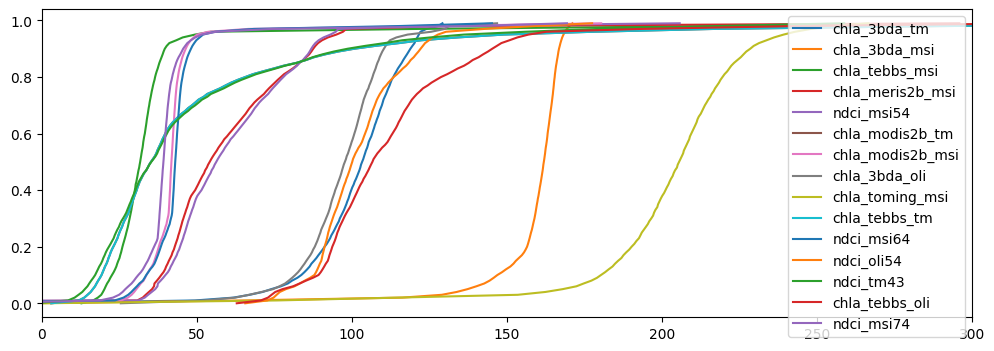

In [623]:
# --- check some of the results ---
#     a little bit of analysis and normalisation to be able to view the results comparatively
rng = np.random.default_rng()
i = rng.integers(size=1,low=0,high=wq_results.place.size).item()
placename = wq_results.place[i].item()
#print(placename)


    
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
plt.xlim(0,300)

exclude = ['chla_tebbs_oli','chla_tebbs_msi','chla_tebbs_tm']
exclude = []

reftime    =  wq_results.time[0:24]   
targettime =  wq_results.time[0:24]  
displaytime = wq_results.time[0:24]

print(placename)

for name in (set(wq_results.chla_measure.values) - set(exclude)):
    scale  =  wq_results.loc[dict(chla_measure = name)].chla_scale.item()
    offset =  wq_results.loc[dict(chla_measure = name)].chla_offset.item()
    #print(scale,offset)
    y = wq_results['quantile'][wq_results['quantile']<1]
    x = ((wq_results.loc[dict(time = (displaytime) ,
                             chla_measure=name ,
                             place = placename,
                             quantile=(wq_results['quantile'] <1))].chla\
                             * scale) + offset).median(dim=('time'))
    plt.plot(x,y,label=name)
plt.legend(loc='best')
plt.show()


Kolokonda


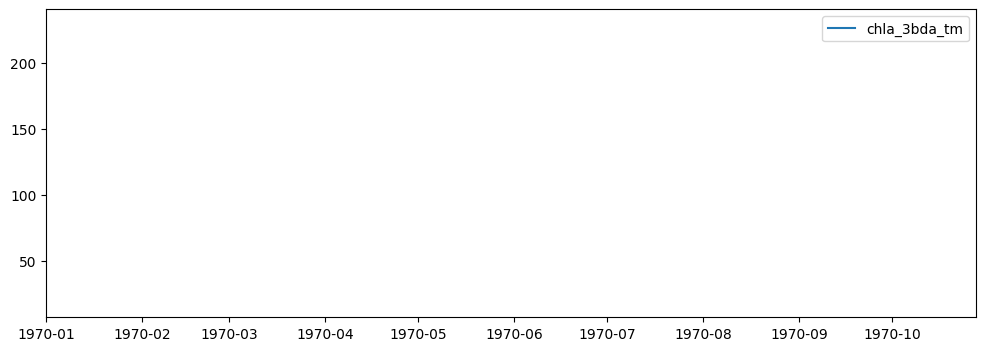

In [630]:
# --- check some of the results ---
#     a little bit of analysis and normalisation to be able to view the results comparatively
rng = np.random.default_rng()
i = rng.integers(size=1,low=0,high=wq_results.place.size).item()
placename = wq_results.place[i].item()
#print(placename)


    
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
plt.xlim(0,300)

exclude = ['chla_tebbs_oli','chla_tebbs_msi','chla_tebbs_tm']
exclude = []

reftime    =  wq_results.time[0:24]   
targettime =  wq_results.time[0:24]  
displaytime = wq_results.time[0:25]

print(placename)

if True:
    #print(scale,offset)
    x = wq_results['time']
    y = ((wq_results.loc[dict(time = (displaytime) ,
                              place = placename,
                              quantile=(wq_results['quantile'] ==.5))].chla\
                             * wq_results.chla_scale) + wq_results.chla_offset).median(dim=('chla_measure')).squeeze()
    plt.plot(x,y,label=name)
plt.legend(loc='best')
plt.show()


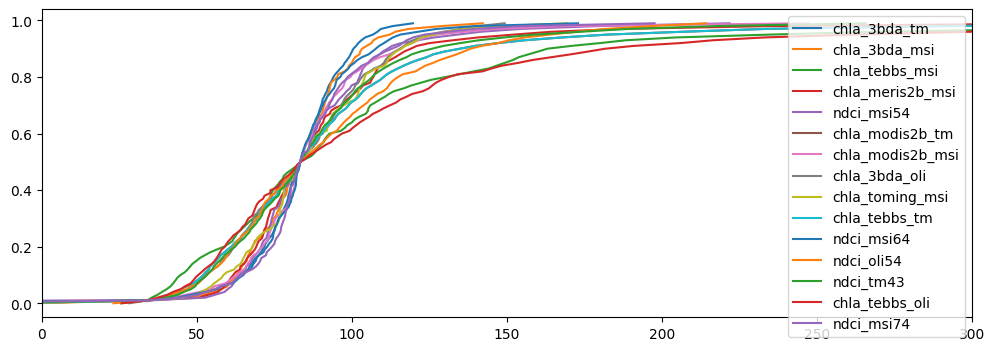

In [534]:
# --- check some of the results ---
#     a little bit of analysis and normalisation to be able to view the results comparatively
rng = np.random.default_rng()
i = rng.integers(size=1,low=0,high=wq_results.place.size).item()
    
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
plt.xlim(0,300)

exclude = ['chla_tebbs_oli','chla_tebbs_msi','chla_tebbs_tm']
exclude = []

reftime    =  wq_results.time[0:24]   
targettime =  wq_results.time[0:24]  
displaytime = wq_results.time[0:24]

for name in (set(wq_results.chla_measure.values) - set(exclude)):
    y = wq_results['quantile'][wq_results['quantile']<1]
    scale  = wq_results.loc[dict(chla_measure=name)].chla_scale
    offset = wq_results.loc[dict(chla_measure=name)].chla_offset
    
    x = (wq_results.loc[dict(time = (displaytime) ,
                             chla_measure=name ,
                             quantile=(wq_results['quantile'] <1))].chla.
                             median(dim=('time','place')) * scale) + offset
    plt.plot(x,y,label=name)
plt.legend(loc='best')
plt.show()


#### Demonstrates the *dynamic application* of the scale and offset parameters:

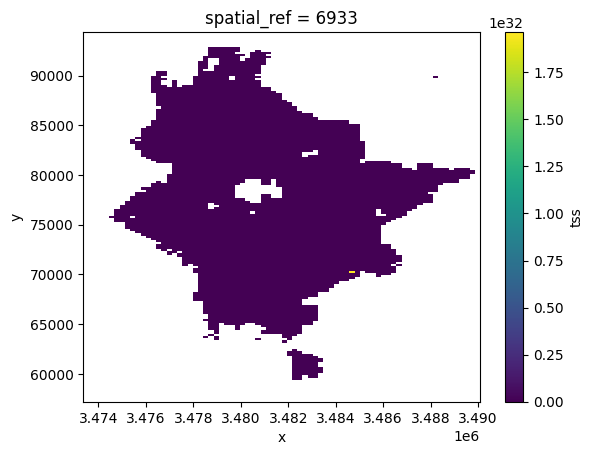

In [542]:
ds.tss.mean(dim=('time','tss_measure')).plot()

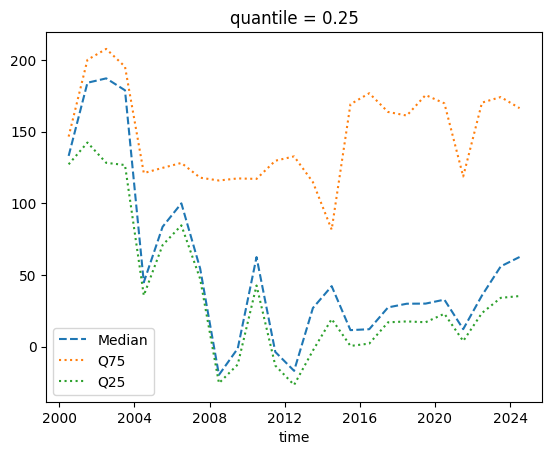

In [480]:
(ds.chla * wq_results.chla_scale + wq_results.chla_offset).median(dim=('chla_measure','x','y')).plot(linestyle = '--',label='Median')
(ds.chla * wq_results.chla_scale + wq_results.chla_offset).quantile(0.75,dim=('chla_measure','x','y')).plot(linestyle=':',label='Q75')
(ds.chla * wq_results.chla_scale + wq_results.chla_offset).quantile(0.25,dim=('chla_measure','x','y')).plot(linestyle=':',label='Q25')
plt.legend(loc='best')

In [609]:
wq_results.

<xarray.DataArray 'chla_measure' (chla_measure: 15)> Size: 960B
array(['ndci_msi54', 'ndci_msi64', 'ndci_msi74', 'ndci_tm43', 'ndci_oli54',
       'chla_toming_msi', 'chla_3bda_msi', 'chla_3bda_oli', 'chla_3bda_tm',
       'chla_tebbs_msi', 'chla_tebbs_oli', 'chla_tebbs_tm', 'chla_meris2b_msi',
       'chla_modis2b_msi', 'chla_modis2b_tm'], dtype='<U16')
Coordinates:
  * chla_measure  (chla_measure) <U16 960B 'ndci_msi54' ... 'chla_modis2b_tm'
    spatial_ref   int32 4B 6933

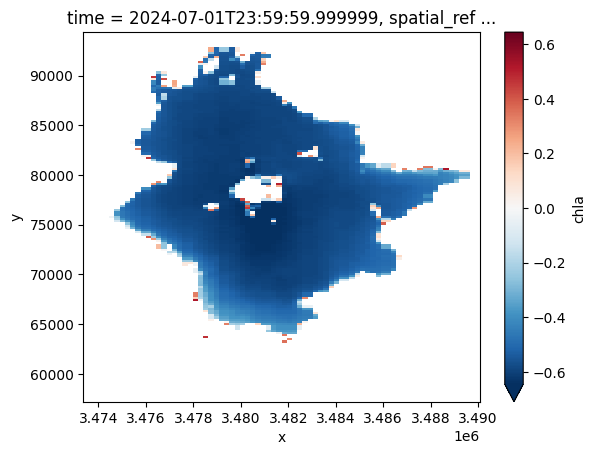

In [614]:
# --- the process seems to be working the way it ought...

(ds.chla* 1 + 0).isel(time=24).loc[dict(chla_measure='chla_modis2b_oli')].plot(robust=True)

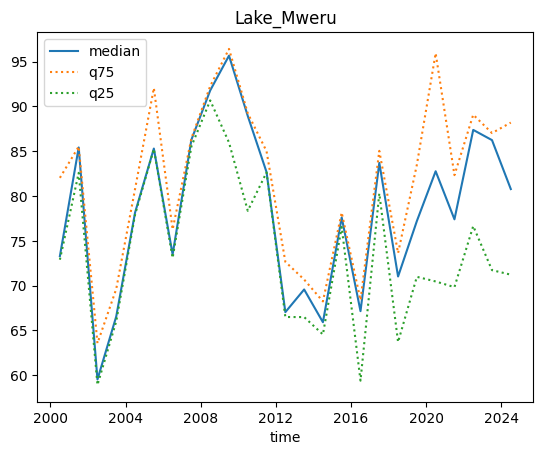

In [662]:
i = i
placename = wq_results.place[i].item()
(wq_results.chla.loc[dict(quantile=(wq_results['quantile'] ==.5))] * wq_results.chla_scale + wq_results.chla_offset).\
    squeeze().sel(place=placename).quantile(0.5,dim='chla_measure').plot(label='median')
(wq_results.chla.loc[dict(quantile=(wq_results['quantile'] ==.5))] * wq_results.chla_scale + wq_results.chla_offset).\
    squeeze().sel(place=placename).quantile(0.75,dim='chla_measure').plot(label='q75',linestyle=':')
(wq_results.chla.loc[dict(quantile=(wq_results['quantile'] ==.5))] * wq_results.chla_scale + wq_results.chla_offset).\
    squeeze().sel(place=placename).quantile(0.25,dim='chla_measure').plot(label='q25',linestyle=':')
plt.title(placename)
plt.legend()
plt.show()
i+=1

/opt/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


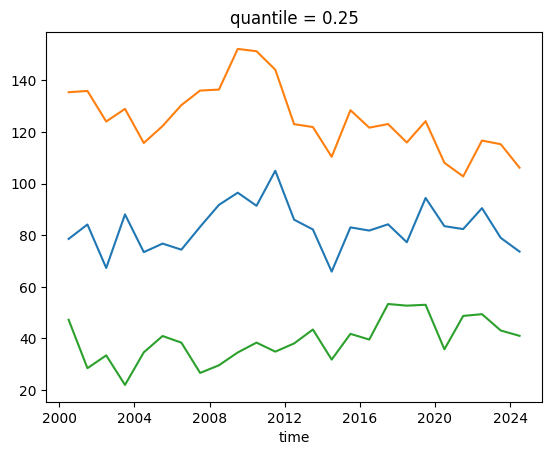

In [589]:
(wq_results.chla.loc[dict(quantile=(wq_results['quantile'] ==.5))] * wq_results.chla_scale + wq_results.chla_offset).\
    squeeze().\
    quantile(0.5,dim=('chla_measure')).\
    quantile(0.75,dim=('place')).plot()
(wq_results.chla.loc[dict(quantile=(wq_results['quantile'] ==.5))] * wq_results.chla_scale + wq_results.chla_offset).\
    squeeze().\
    quantile(0.5,dim=('chla_measure')).\
    quantile(0.25,dim=('place')).plot()

                                   

#### TSS :


Ghana_River


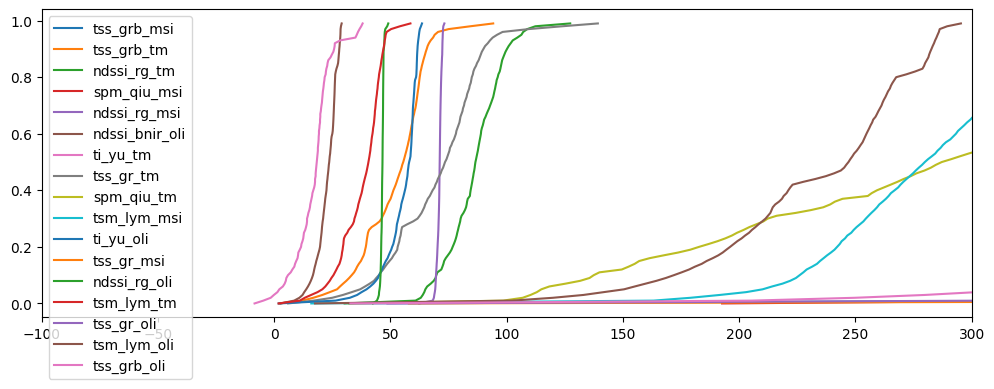

In [736]:
# --- check some of the results ---
#     a little bit of analysis and normalisation to be able to view the results comparatively
#rng = np.random.default_rng()
#i = rng.integers(size=1,low=0,high=wq_results.place.size).item()
i = i
placename = wq_results.place[i].item()
#print(placename)


    
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
plt.xlim(-100,300)

exclude = ['chla_tebbs_oli','chla_tebbs_msi','chla_tebbs_tm']
exclude = []

reftime    =  wq_results.time[0:24]   
targettime =  wq_results.time[0:24]  
displaytime = wq_results.time[0:24]

print(placename)

for name in (set(wq_results.tss_measure.values) - set(exclude)):
    scale  =  wq_results.loc[dict(tss_measure = name)].tss_scale.item()
    offset =  wq_results.loc[dict(tss_measure = name)].tss_offset.item()
    y = wq_results['quantile'][wq_results['quantile']<1]
    x = (wq_results.loc[dict(time = (displaytime) ,
                             tss_measure=name ,
                             place = placename,
                             quantile=(wq_results['quantile'] <1))].tss.
                             median(dim=('time')) * scale) + offset
    plt.plot(x,y,label=name)
plt.legend(loc='best')
plt.show()
i +=1

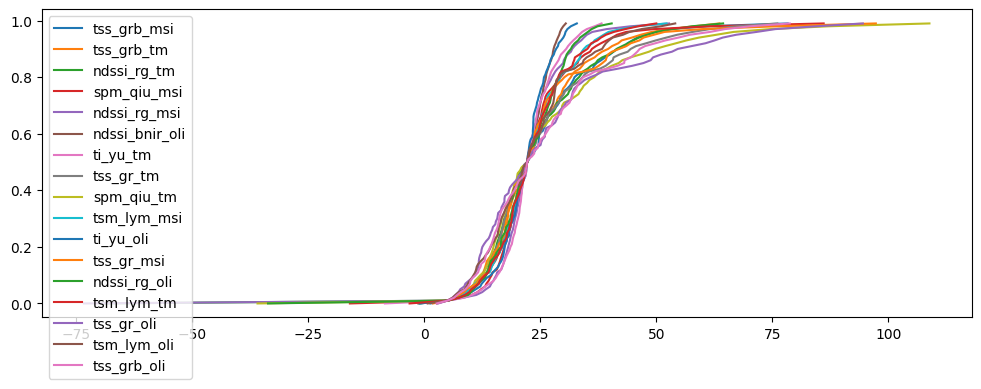

In [741]:
# --- check some of the results ---
#     a little bit of analysis and normalisation to be able to view the results comparatively
   
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
#plt.xlim(0,300)

exclude = []

reftime    =  wq_results.time[0:24]   
targettime =  wq_results.time[0:24]  
displaytime = wq_results.time[0:24]

for name in (set(wq_results.tss_measure.values) - set(exclude)):
    y = wq_results['quantile'][wq_results['quantile']<1]
    scale  = wq_results.loc[dict(tss_measure=name)].tss_scale
    offset = wq_results.loc[dict(tss_measure=name)].tss_offset
    

    x = (wq_results.loc[dict(time = (displaytime) ,
                             tss_measure=name ,
                             quantile=(wq_results['quantile'] <1))].tss.
                             median(dim=('time','place')) * scale) + offset
    plt.plot(x,y,label=name)
plt.legend(loc='best')
plt.show()


In [721]:
log[log.PlaceName=='Barrage Joumine']

,Unnamed: 0,PlaceName,Status,RunNumber,Year1,Year2,x0,x1,y0,y1,t0,t1,CellArea,Resampling
47,47,Barrage Joumine,100,110,2000,2024,9.53,9.62,36.952,37.0,2000,2024,0.0025,bilinear
